   Порог (k)  Вер-ть прохождения (сильный), %  Вер-ть прохождения (слабый), %
0         16                           100.00                           95.68
1         17                            99.94                           86.70
2         18                            99.29                           67.69
3         19                            94.01                           39.17
4         20                            66.76                           12.16


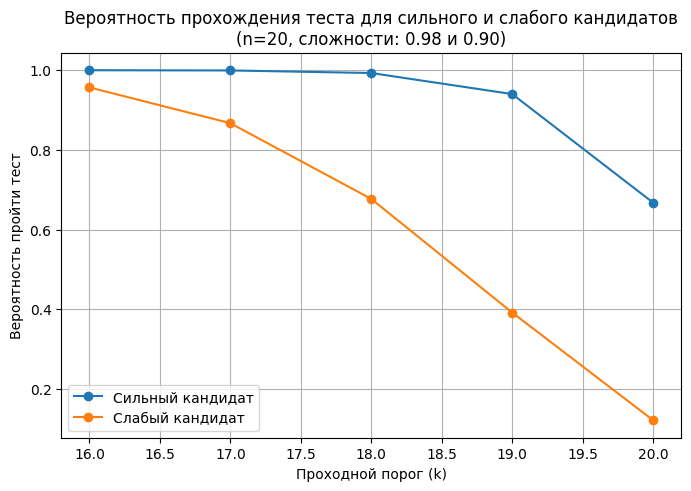

In [6]:
#шаг 2
from scipy.stats import binom
import matplotlib.pyplot as plt
import pandas as pd
n = 20
p_strong = 0.98
p_weak = 0.9
ks = range(16, n + 1)
probs_strong = [1 - binom.cdf(k - 1, n, p_strong) for k in ks]
probs_weak = [1 - binom.cdf(k - 1, n, p_weak) for k in ks]
df = pd.DataFrame({
    'Порог (k)': ks,
    'Вер-ть прохождения (сильный), %': [round(p * 100, 2) for p in probs_strong],
    'Вер-ть прохождения (слабый), %': [round(p * 100, 2) for p in probs_weak]
})
print(df)
plt.figure(figsize=(8, 5))
plt.plot(ks, probs_strong, label='Сильный кандидат', marker='o')
plt.plot(ks, probs_weak, label='Слабый кандидат', marker='o')
plt.xlabel('Проходной порог (k)')
plt.ylabel('Вероятность пройти тест')
plt.title('Вероятность прохождения теста для сильного и слабого кандидатов\n(n=20, сложности: 0.98 и 0.90)')
plt.legend()
plt.grid(True)
plt.show()


    Вопросов (n)  Порог (k)  Вер-ть прохождения сильного, %  \
0             24         23                           91.74   
1             25         24                           91.14   
2             26         25                           90.52   
3             27         26                           89.89   
4             28         27                           89.25   
5             29         28                           88.60   
6             30         29                           87.95   
7             31         30                           87.28   
8             32         31                           86.60   
9             33         32                           85.92   
10            34         33                           85.23   

    Вер-ть исключения слабого, %  
0                          70.75  
1                          72.88  
2                          74.87  
3                          76.74  
4                          78.48  
5                          80.11 

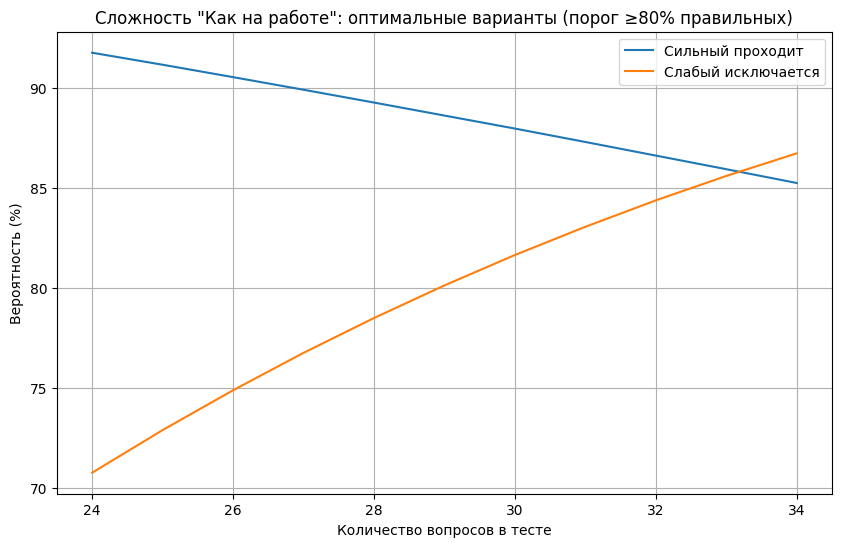

In [7]:
#шаг 3-4
import numpy as np
n_range = range(15, 35)
results = []
for n in n_range:
    found = False
    for k in range(int(0.8*n), n+1):
        prob_strong = 1 - binom.cdf(k-1, n, p_strong)
        prob_weak_exclude = binom.cdf(k-1, n, p_weak)
        if (prob_strong >= 0.8) and (prob_weak_exclude >= 0.7):
            results.append({
                'Вопросов (n)': n,
                'Порог (k)': k,
                'Вер-ть прохождения сильного, %': round(prob_strong*100,2),
                'Вер-ть исключения слабого, %': round(prob_weak_exclude*100,2)
            })
            found = True
            break
df = pd.DataFrame(results)
print(df)
plt.figure(figsize=(10,6))
plt.plot(df['Вопросов (n)'], df['Вер-ть прохождения сильного, %'], label='Сильный проходит')
plt.plot(df['Вопросов (n)'], df['Вер-ть исключения слабого, %'], label='Слабый исключается')
plt.xlabel('Количество вопросов в тесте')
plt.ylabel('Вероятность (%)')
plt.title('Сложность \"Как на работе\": оптимальные варианты (порог ≥80% правильных)')
plt.legend()
plt.grid(True)
plt.show()



   Вопросов (n)  Порог (k)  Сильный проходит, %  Слабый исключается, %
0            49         48                91.36                  71.01
1            50         49                91.06                  72.06


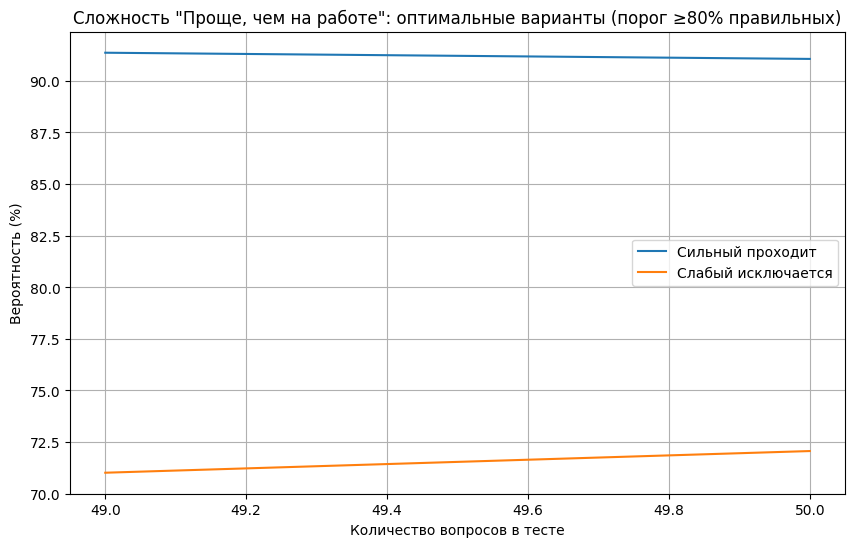

In [8]:
#шаг 5
p_strong = 0.99
p_weak = 0.95
n_range = range(15, 51)
results = []
for n in n_range:
    found = False
    for k in range(int(0.8*n), n+1):
        prob_strong = 1 - binom.cdf(k-1, n, p_strong)
        prob_weak_exclude = binom.cdf(k-1, n, p_weak)
        if (prob_strong >= 0.8) and (prob_weak_exclude >= 0.7):
            results.append({
                'Вопросов (n)': n,
                'Порог (k)': k,
                'Сильный проходит, %': round(prob_strong*100,2),
                'Слабый исключается, %': round(prob_weak_exclude*100,2)
            })
            found = True
            break
df = pd.DataFrame(results)
print(df)
plt.figure(figsize=(10,6))
plt.plot(df['Вопросов (n)'], df['Сильный проходит, %'], label='Сильный проходит')
plt.plot(df['Вопросов (n)'], df['Слабый исключается, %'], label='Слабый исключается')
plt.xlabel('Количество вопросов в тесте')
plt.ylabel('Вероятность (%)')
plt.title('Сложность \"Проще, чем на работе\": оптимальные варианты (порог ≥80% правильных)')
plt.legend()
plt.grid(True)
plt.show()

   Вопросов (n)  Порог (k)  Сильный проходит, %  Слабый исключается, %
0             4          2                91.63                  81.92
1             5          3                83.69                  94.21
2             7          4                87.40                  96.67
3             8          5                80.59                  98.96


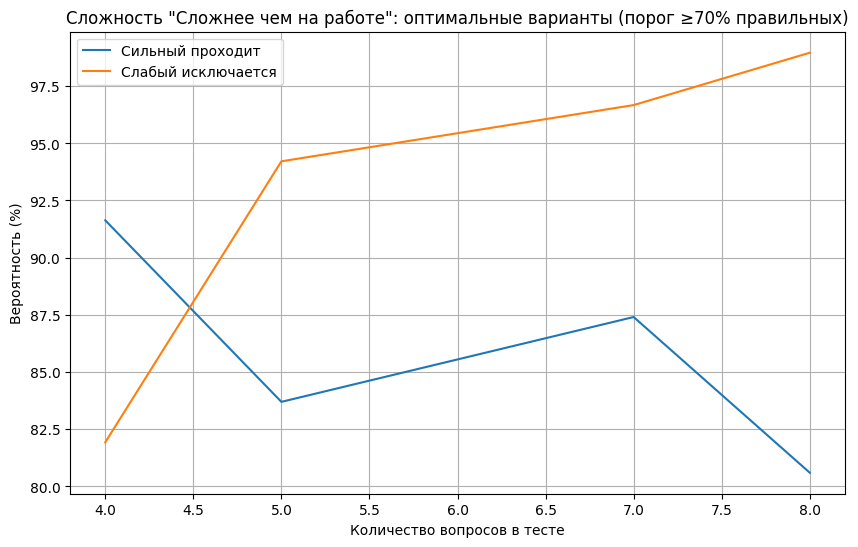

In [16]:
#шаг 6
p_strong = 0.7
p_weak = 0.2
n_range = range(2, 50)
results = []
for n in n_range:
    found = False
    for k in range(int(0.7*n), n+1):
        prob_strong = 1 - binom.cdf(k-1, n, p_strong)
        prob_weak_exclude = binom.cdf(k-1, n, p_weak)
        if (prob_strong >= 0.8) and (prob_weak_exclude >= 0.7):
            results.append({
                'Вопросов (n)': n,
                'Порог (k)': k,
                'Сильный проходит, %': round(prob_strong*100,2),
                'Слабый исключается, %': round(prob_weak_exclude*100,2)
            })
            found = True
            break
df = pd.DataFrame(results)
print(df)
plt.figure(figsize=(10,6))
plt.plot(df['Вопросов (n)'], df['Сильный проходит, %'], label='Сильный проходит')
plt.plot(df['Вопросов (n)'], df['Слабый исключается, %'], label='Слабый исключается')
plt.xlabel('Количество вопросов в тесте')
plt.ylabel('Вероятность (%)')
plt.title('Сложность \"Сложнее чем на работе\": оптимальные варианты (порог ≥70% правильных)')
plt.legend()
plt.grid(True)
plt.show()